In [16]:
import numpy as np
import math
import matplotlib.pyplot as plt

In [45]:
def LUdecomp(A):
    n = A.shape[0]
    m = A.shape[1]

    pivot = np.zeros(n)
    for i in range(n):
        pivot[i] = i+1

    det = 1
    for j in range(0,n-1):
        p = j
        Amax = abs(A[j,j])
        for k in range(j+1,n):
            if abs(A[k,j]) > Amax:
                Amax = abs(A[k,j])
                p = k
            
        if p != j:
            for k in range(0,m):
                t = A[j,k]
                A[j,k] = A[p,k]
                A[p,k] = t
            
            s = pivot[j]
            pivot[j] = pivot[p]
            pivot[p] = s
            det = -det
        
        det = det*A[j,j]
        if A[j,j] != 0:
            r = 1/A[j,j]
            for i in range(j+1,n):
                mult = A[i,j]*r
                A[i,j] = mult
                for k in range(j+1,m):
                    A[i,k] = A[i,k] - mult*A[j,k]

    det = det*A[n-1,n-1]
    return (A, det, pivot)

def getL(LU):
    n = LU.shape[0]
    m = LU.shape[1]

    L = np.zeros((n,m))
    for i in range(n):
        for j in range(m):
            if i == j:
                L[i,j] = 1
            elif i > j:
                L[i,j] = LU[i,j]
    
    return L

def getU(LU):
    n = LU.shape[0]
    m = LU.shape[1]

    U = np.zeros((n,m))
    for i in range(n):
        for j in range(m):
            if i <= j:
                U[i,j] = LU[i,j]
    
    return U

def solveL(L, pivot, b):
    n = L.shape[0]

    y = np.zeros(n)
    k = int(pivot[0])
    y[0] = b[k-1]
    for i in range(1,n):
        soma = 0
        for j in range(0,i):
            soma = soma + L[i,j]*y[j]
            
        k = int(pivot[i])
        #tive que fazer essa adaptação porque o algorítmo do material não é genérico o suficiente
        #para permitir que seja qualquer matrix triangular inferior
        y[i] = (b[k-1] - soma)/L[i,i]

    return y

def solveU(U, y):
    n = U.shape[0]
    x = np.zeros(n)

    x[n-1] = y[n-1]/U[n-1,n-1]
    for i in reversed(range(0,n-1)):
        soma = 0
        for j in range(i+1,n):
            soma = soma + U[i,j]*x[j]

        x[i] = (y[i] - soma)/U[i,i]

    return x

def solveLU(A, b):
    LU, det, pivot = LUdecomp(A)
    L = getL(LU)
    U = getU(LU)
    y = solveL(L, pivot, b)
    x = solveU(U, y)
    return x

def choleskydecomp(A):
    n = A.shape[0]
    
    conderro = 0
    det = 1
    r = 1
    t = 1
    soma = 0
    for j in range(0,n):
        soma = 0
        for k in range(0,j):
            soma = soma + A[j,k]**2

        t = A[j,j] - soma
        if t > 0:
            A[j,j] = math.sqrt(t)
            r = 1/A[j,j]
            det = det*t
        else:
            conderro = 1
            print("Erro: matriz não definida positiva")
            return (A, conderro, det)
        
        for i in range(j+1,n):
            soma = 0
            for k in range(0,j):
                soma = soma + A[i,k]*A[j,k]

            A[i,j] = (A[i,j] - soma)*r
            #algorítmo no material retornava uma matriz que não era triangular inferior (ele não mexia nos elementos acima da diagonal)
            A[j,i] = 0

    return (A, conderro, det)

def solvecholesky(A, b):
    G, conderro, det = choleskydecomp(A)
    #cholesky não faz pivoteamento, pivot vai ser só [1,2,3]
    pivot = np.arange(1, A.shape[0]+1)
    y = solveL(G, pivot, b)
    x = solveU(G.T, y)
    return x

def solvegauss_seidel(A, b, tol, itermax):
    n = A.shape[0]
    x = np.zeros(n)
    v = np.zeros(n)
    for i in range(0,n):
        r = 1/A[i,i]
        for j in range(0,n):
            if i != j:
                A[i,j] = A[i,j]*r
            
        #A[i,i] = 0
        b[i] = b[i]*r
        x[i] = b[i]
        
    iter = 0
    normarel = 1
    while iter <= itermax:
        iter = iter + 1
        for i in range(0,n):
            soma = 0
            for j in range(0,n):
                if i != j: 
                    soma = soma + A[i,j]*x[j]
            
            v[i] = x[i]
            x[i] = b[i] - soma

        normanum = 0    
        normaden = 0
        for i in range(0,n):
            t = abs(v[i] - x[i])
            normanum = normanum + t**2
            normaden = normaden + abs(v[i])**2

        normarel = math.sqrt(normanum/normaden)
        if normarel <= tol:
            conderro = 0
        else:
            conderro = 1
        

    return x, normarel, conderro

In [5]:
def formatacaough(A):
    for i in range(A.shape[0]):
        if len(A.shape) == 2:
            for j in range(A.shape[1]):
                print("[{0:^9}]".format("%.3g" % A[i,j]), end='')
        else:
            print("[{0:^9}]".format("%.3g" % A[i]), end='')

        print()

In [63]:
#não tem nada sobre ajuste funcional no material
def discretenorm(u, v):
    if len(u) != len(v):
        raise ValueError("Vectors must have the same length")

    return sum([u[i]*v[i] for i in range(len(u))])

def discretepolynfit(x, y, n):
    M = np.zeros((n+1,n+1))
    b = np.zeros(n+1)
    for i in range(n+1):
        for j in range(n+1):
            M[i,j] = discretenorm(x**i, x**j)
        
        b[i] = discretenorm(y, x**i)

    #NOTE: acho que essa matriz é simétrica sempre
    return solveLU(M, b)

def discreteexponentialfit(x, y):
    M = np.zeros((2,2))
    b = np.zeros(2)
    for i in range(2):
        for j in range(2):
            M[i,j] = discretenorm(x**i, x**j)
        
        b[i] = discretenorm(np.log(y), x**i)

    return solveLU(M, b)

In [60]:
x = np.array([0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0])
y = np.array([1.0, 0.5, 4.1, 3.65, 7.0, 6.5, 10.0, 10.55, 12.6, 12.05, 14.5])

coeff = discretepolynfit(x, y, 1)
print(coeff)

[0.40454545 1.41818182]


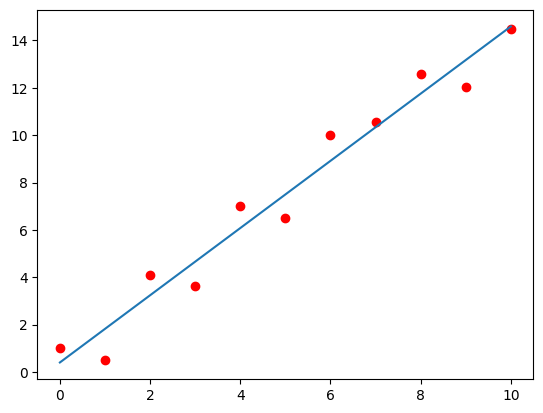

In [61]:
plt.plot(x, y, 'ro')
f = lambda x: sum([coeff[i]*x**i for i in range(len(coeff))])
x = np.linspace(0, 10, 100)
plt.plot(x, f(x))
plt.show()

[0.68712201 1.00195861]


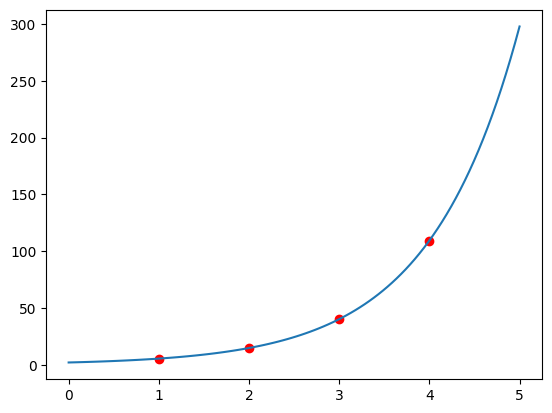

In [73]:
x = np.array([1., 2., 3., 4.])
y = np.array([5.4, 14.8, 40.2, 109.2])

coeff = discreteexponentialfit(x, y)
print(coeff)
plt.plot(x, y, 'ro')
f = lambda x: np.exp(coeff[0])*np.exp(coeff[1])**x
x = np.linspace(0, 5, 100)
plt.plot(x, f(x))
plt.show()